In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, f1_score
from sklearn.model_selection import cross_val_score


from google.colab import files

warnings.filterwarnings('ignore')


In [ ]:
# The file to upload can be found in the following link
# https://github.com/5-M-4-Z/FYP/blob/main/Single%20Patch/Python%20code%20for%20creating%20master%20data/Master%20Data%20file.xlsx
# Upload file manually
uploaded = files.upload()


Saving Master Data file.xlsx to Master Data file (1).xlsx


In [ ]:

# Get the first uploaded file name
file_name = list(uploaded.keys())[0]

# Read the Excel file
data = pd.read_excel(file_name, engine='openpyxl')

In [ ]:
# Show first few rows
data.head(20)


,Patch Width,Patch Length,Patch X,Patch Y,Feed X,Feed Y,Truncation along X,Truncation along Y,Peak Frequency,S11 dB value,Axial Ratio at Fr (dB)
0,45.0,45.0,22.5,22.5,44.365,30.978,6.0,6.0,1.56800,-18.514162,2.820222
1,45.0,45.0,22.5,22.5,44.365,31.003,6.0,6.0,1.56650,-18.186538,3.015029
2,45.0,45.0,22.5,22.5,44.365,31.029,6.0,6.0,1.56305,-19.788660,3.839766
3,45.0,45.0,22.5,22.5,44.365,31.054,6.0,6.0,1.56770,-17.375925,2.785259
4,45.0,45.0,22.5,22.5,44.365,31.079,6.0,6.0,1.56140,-21.286046,4.307828
5,45.0,45.0,22.5,22.5,44.365,31.105,6.0,6.0,1.56140,-21.367444,4.081727
6,45.0,45.0,22.5,22.5,44.365,31.130,6.0,6.0,1.56410,-20.662168,3.577049
7,45.0,45.0,22.5,22.5,44.365,31.155,6.0,6.0,1.56725,-18.701728,2.912535
8,45.0,45.0,22.5,22.5,44.365,31.181,6.0,6.0,1.56515,-17.542209,3.318245
9,45.0,45.0,22.5,22.5,44.365,31.206,6.0,6.0,1.56815,-18.618918,2.688278



Correlation Heatmap Analysis


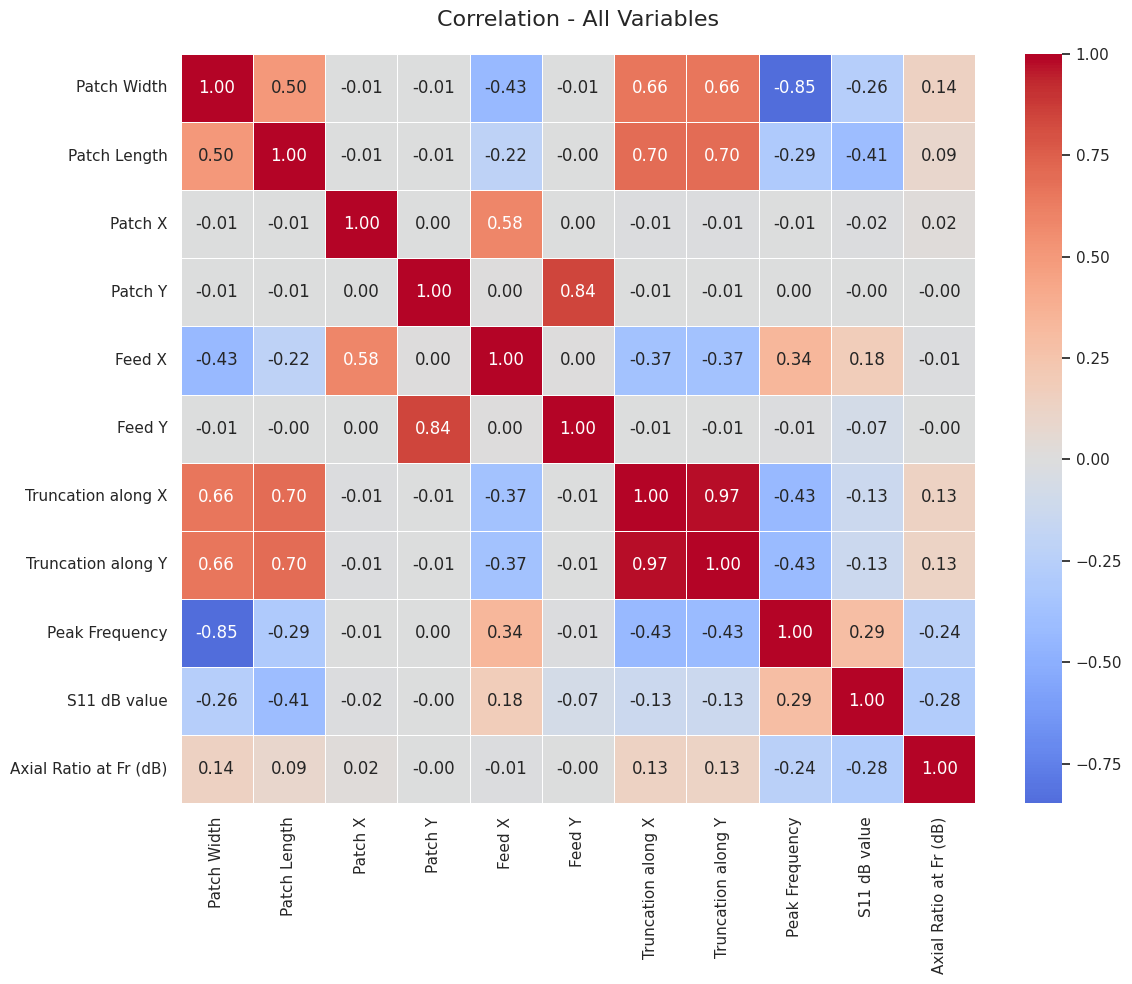

In [ ]:
# --- Correlation Heatmap ---
print(f"\n{'='*65}")
print("Correlation Heatmap Analysis")
print(f"{'='*65}")

# Calculate correlation matrix for all variables (inputs + outputs)
correlation_matrix = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation - All Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Checking same results on different input parameters


In [ ]:
# Columns to compare for identical outputs
output_cols = ["Peak Frequency", "S11 dB value", "Axial Ratio at Fr (dB)"]

# Group by output columns to find duplicates
duplicate_groups = data.groupby(output_cols)

# Find only those groups that appear more than once
duplicates = [group for _, group in duplicate_groups if len(group) > 1]

# Display duplicates, if any
if duplicates:
    print("Rows with same output values but possibly different inputs:")
    for i, group in enumerate(duplicates, start=1):
        print(f"\n--- Duplicate Group {i} ---")
        print(group)
else:
    print("No rows found with same Peak Frequency, S11 dB value, and Axial Ratio values.")

No rows found with same Peak Frequency, S11 dB value, and Axial Ratio values.


# Using Boxplot for outlier visulaization

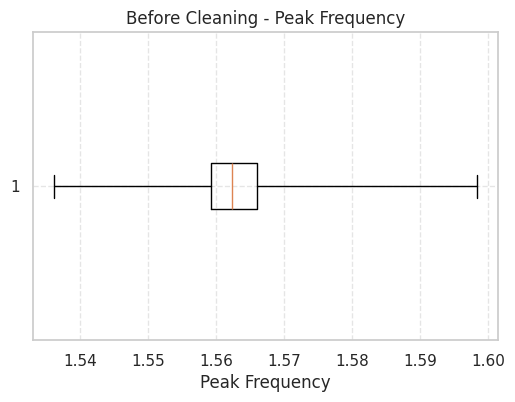

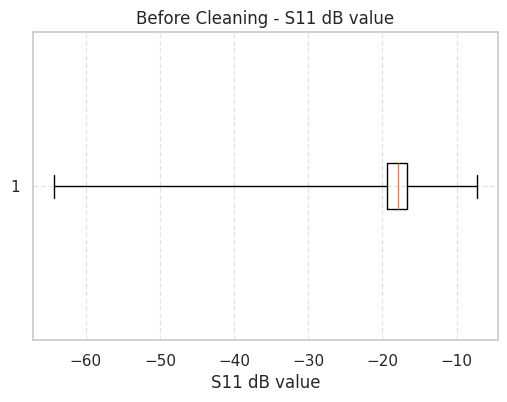

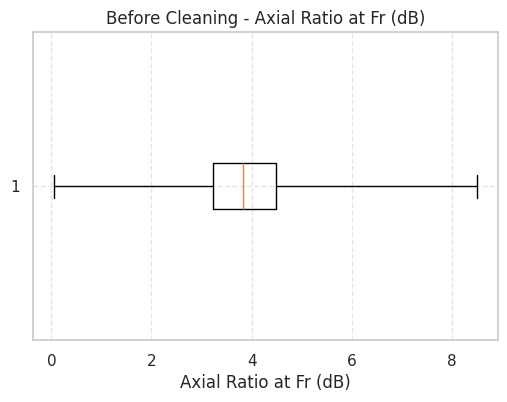

In [ ]:
output_cols = ["Peak Frequency", "S11 dB value", "Axial Ratio at Fr (dB)"]

for col in output_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(data[col], vert=False, whis=[0 ,100])  # flip axes
    plt.title(f"Before Cleaning - {col}")
    plt.xlabel(col)  # now the x-axis label
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

In [ ]:
# Copy original data to avoid overwriting
df_cleaned = data.copy()

for col in output_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Keep only data within bounds
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]

print("Original data size:", len(data))
print("After removing outliers:", len(df_cleaned))


Original data size: 9635
After removing outliers: 7376


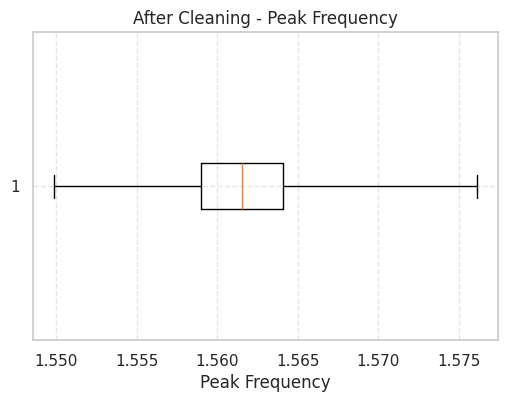

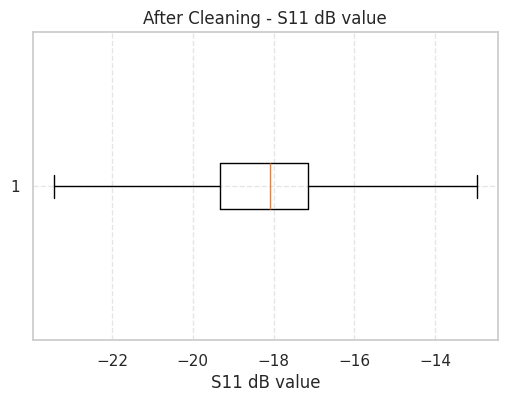

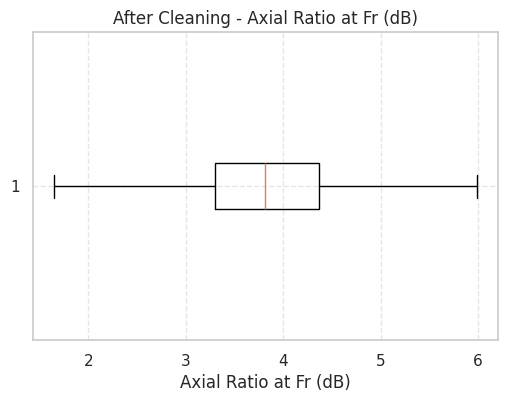

In [ ]:
for col in output_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df_cleaned[col], vert=False, whis=[0,100])
    plt.title(f"After Cleaning - {col}")
    plt.xlabel(col)  # x-axis label
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

In [ ]:
df_cleaned = df_cleaned.reset_index(drop=True)
df_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patch Width             7376 non-null   float64
 1   Patch Length            7376 non-null   float64
 2   Patch X                 7376 non-null   float64
 3   Patch Y                 7376 non-null   float64
 4   Feed X                  7376 non-null   float64
 5   Feed Y                  7376 non-null   float64
 6   Truncation along X      7376 non-null   float64
 7   Truncation along Y      7376 non-null   float64
 8   Peak Frequency          7376 non-null   float64
 9   S11 dB value            7376 non-null   float64
 10  Axial Ratio at Fr (dB)  7376 non-null   float64
dtypes: float64(11)
memory usage: 634.0 KB


In [ ]:
data = df_cleaned.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patch Width             7376 non-null   float64
 1   Patch Length            7376 non-null   float64
 2   Patch X                 7376 non-null   float64
 3   Patch Y                 7376 non-null   float64
 4   Feed X                  7376 non-null   float64
 5   Feed Y                  7376 non-null   float64
 6   Truncation along X      7376 non-null   float64
 7   Truncation along Y      7376 non-null   float64
 8   Peak Frequency          7376 non-null   float64
 9   S11 dB value            7376 non-null   float64
 10  Axial Ratio at Fr (dB)  7376 non-null   float64
dtypes: float64(11)
memory usage: 634.0 KB


# Now applying Linear Regression Algorithm

Input features: ['Patch Width', 'Patch Length', 'Patch X', 'Patch Y', 'Feed X', 'Feed Y', 'Truncation along X', 'Truncation along Y']
Output features: ['Peak Frequency', 'S11 dB value', 'Axial Ratio at Fr (dB)']

Modeling for Output: Peak Frequency
MAE  = 0.0028
MSE  = 0.0000
RMSE = 0.0035
R²   = 0.2491


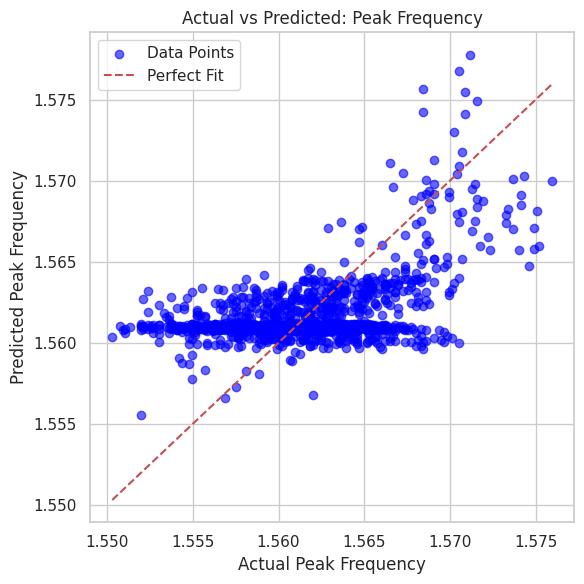

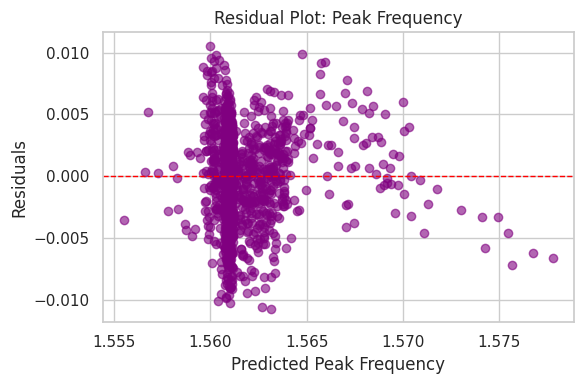


Modeling for Output: S11 dB value
MAE  = 1.3068
MSE  = 2.8560
RMSE = 1.6900
R²   = 0.2143


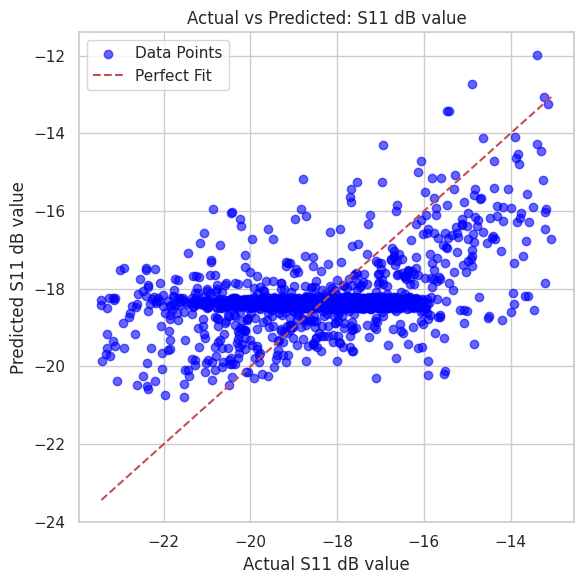

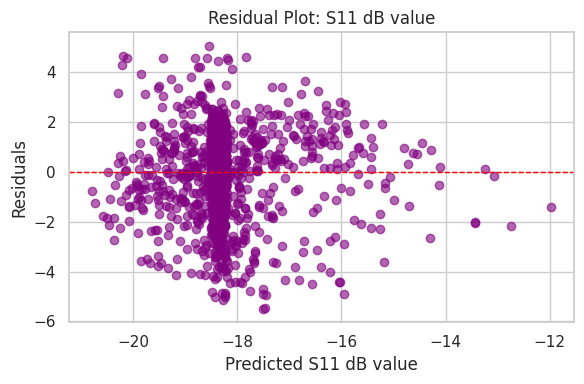


Modeling for Output: Axial Ratio at Fr (dB)
MAE  = 0.5796
MSE  = 0.5128
RMSE = 0.7161
R²   = 0.1661


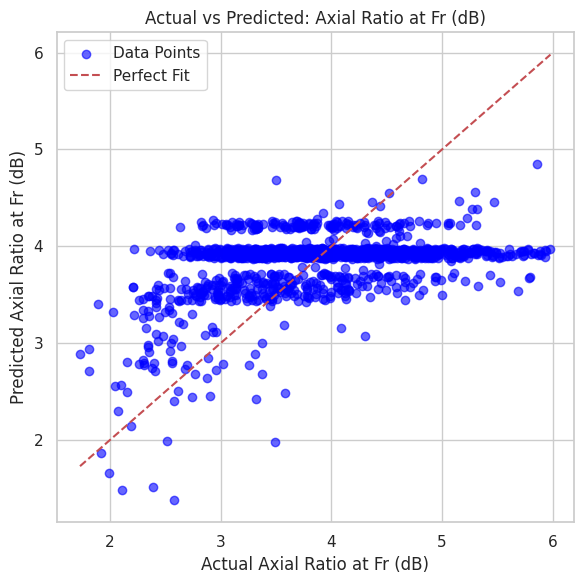

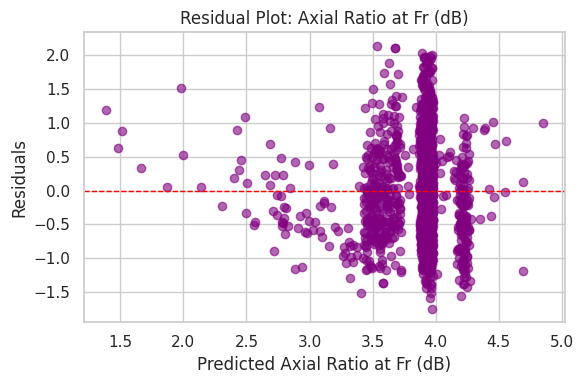


Input vs Output Relationships (Scatter Plots with Fitted Lines)


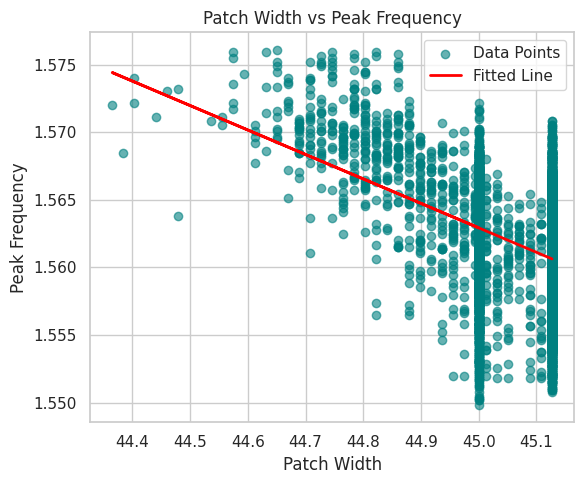

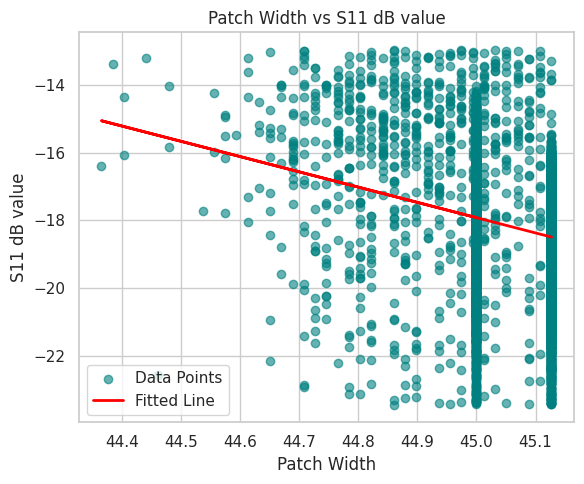

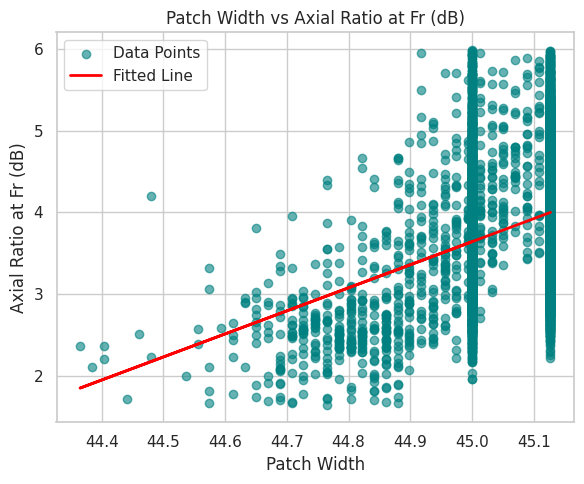

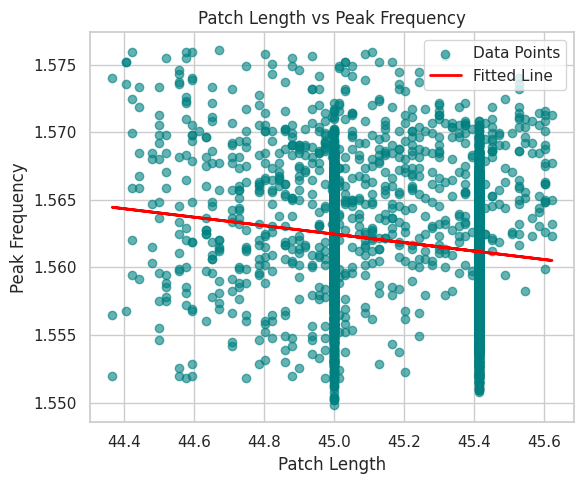

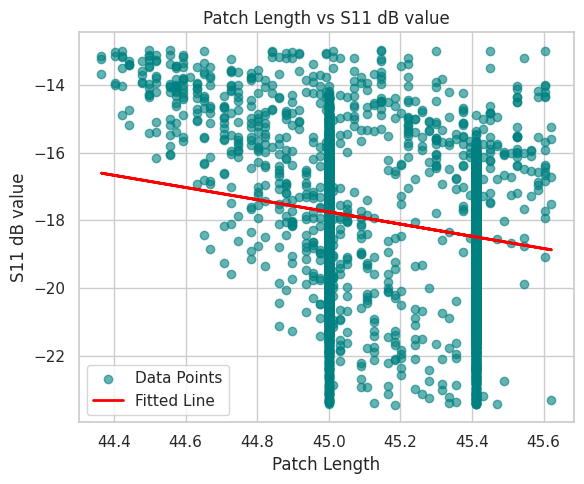

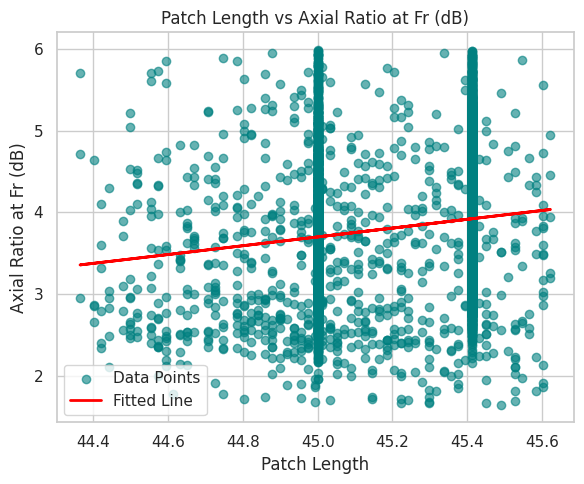

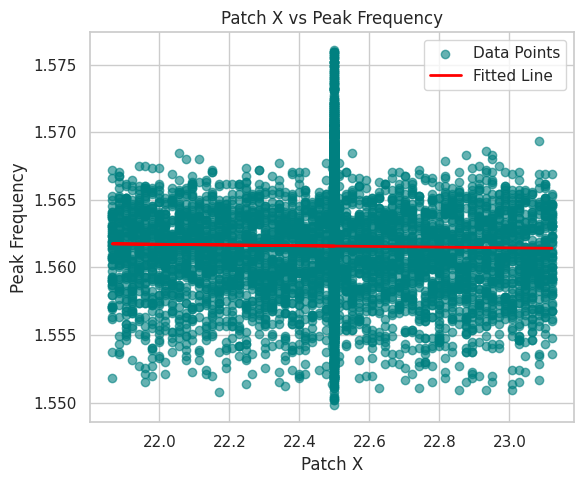

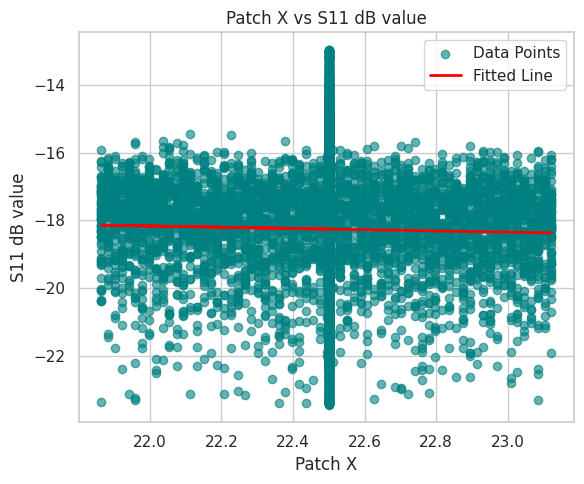

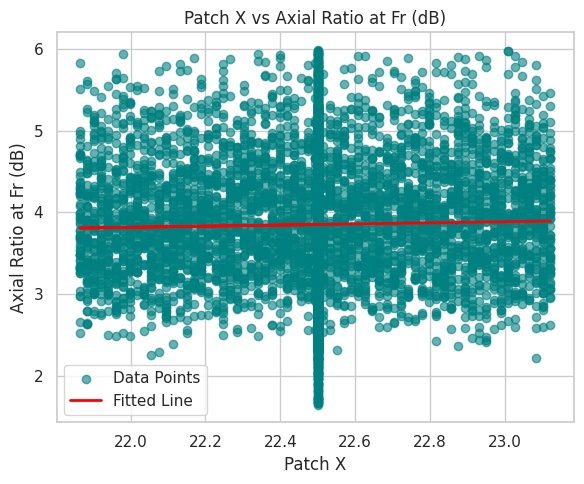

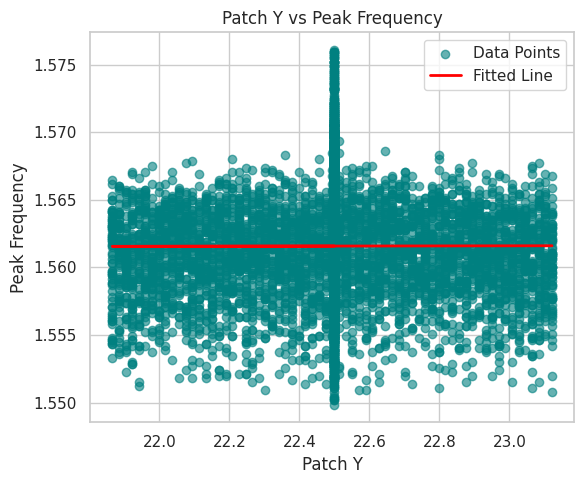

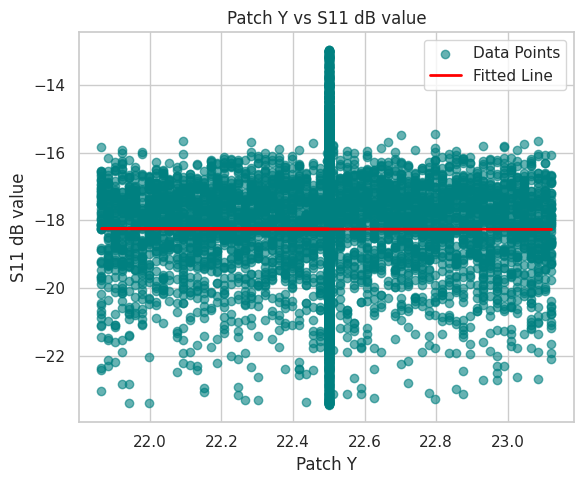

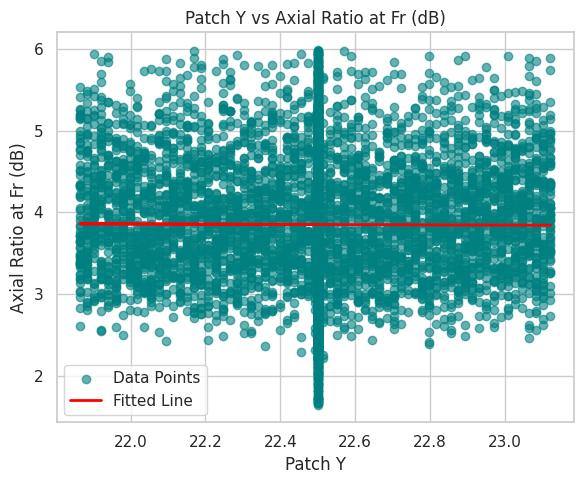

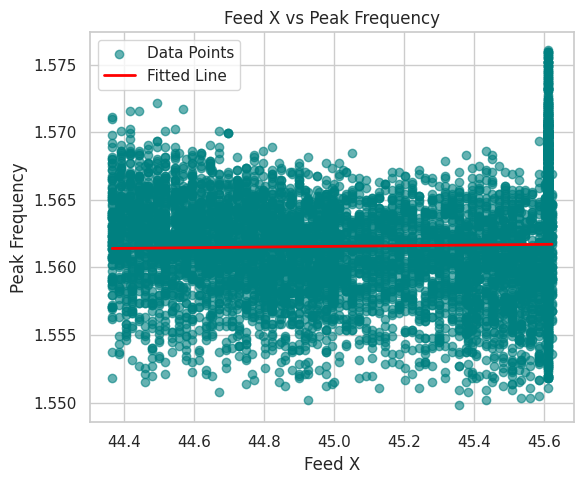

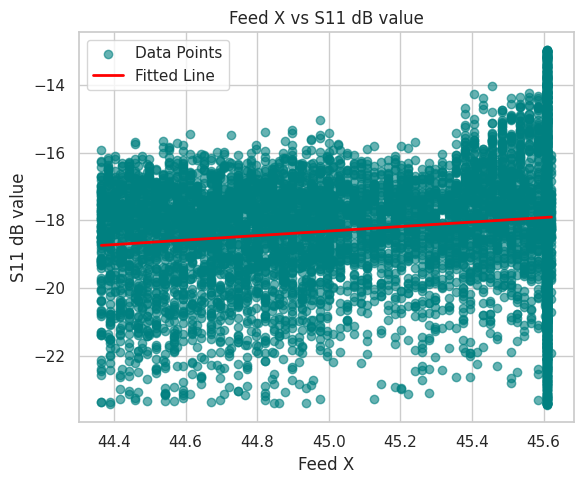

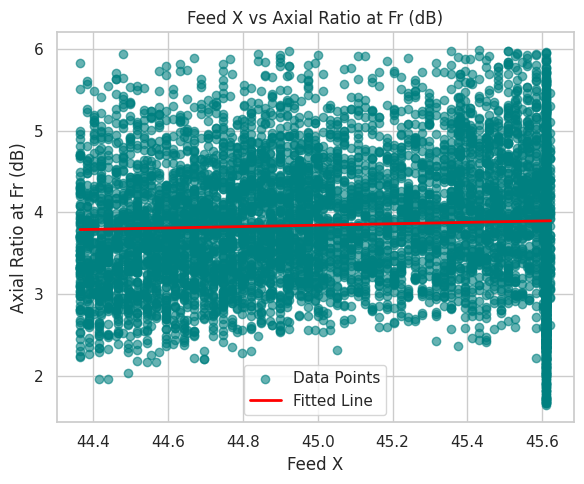

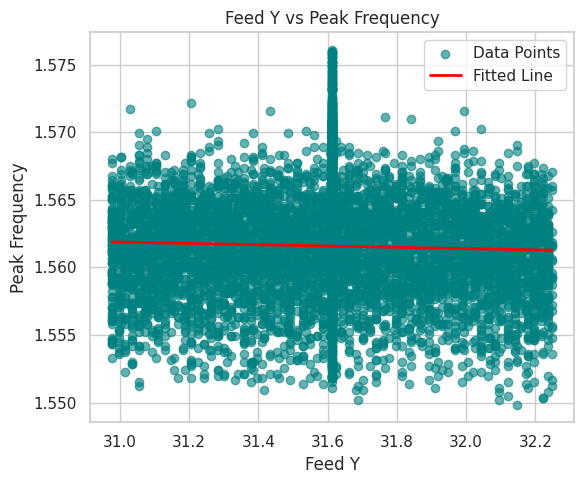

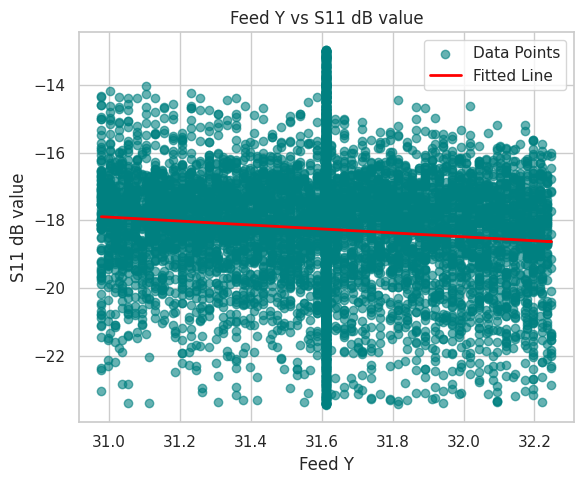

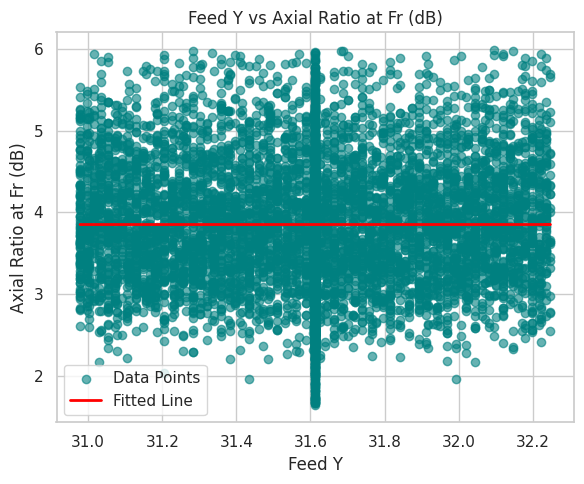

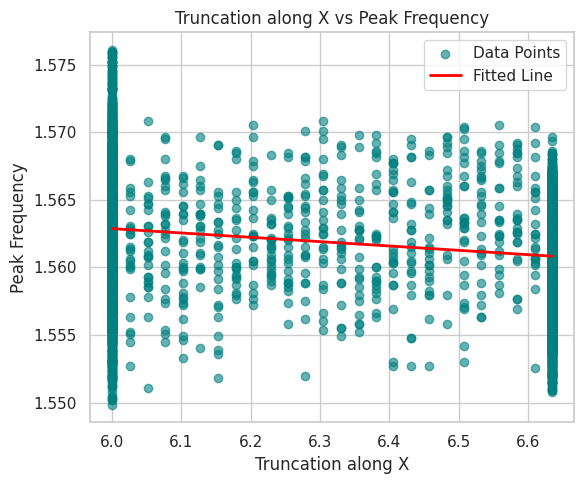

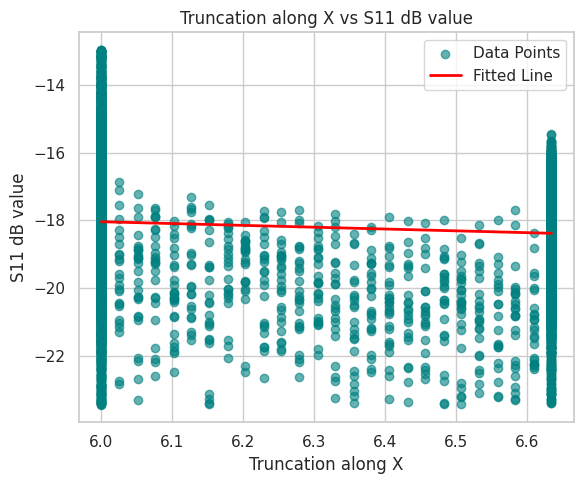

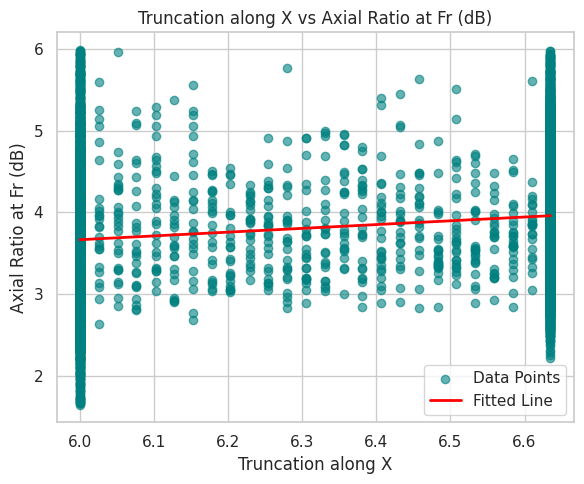

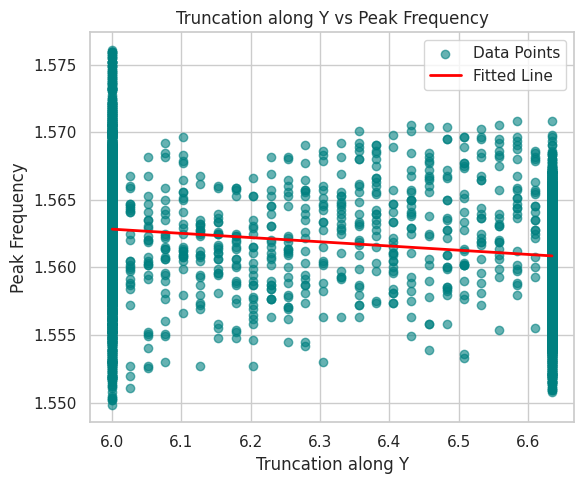

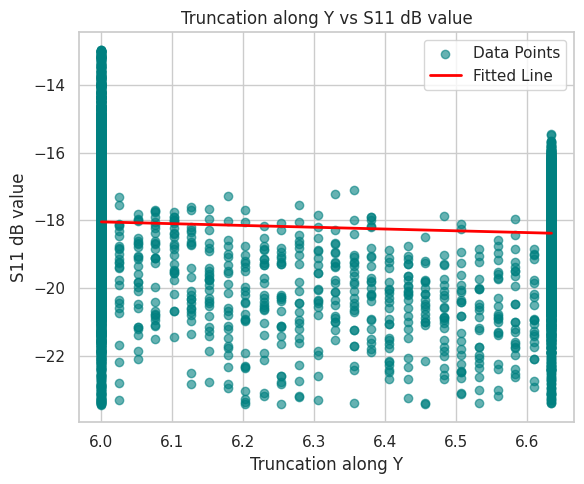

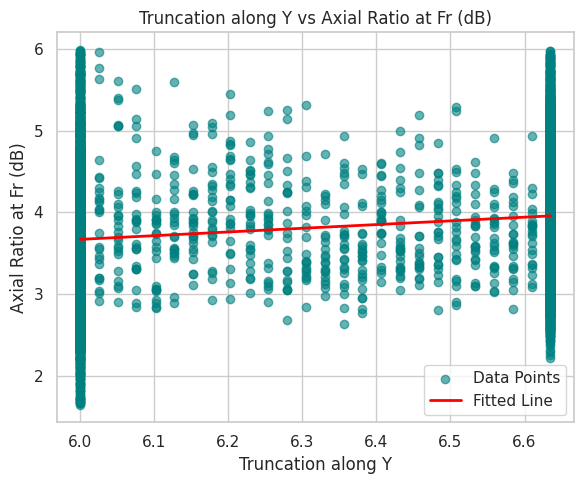


Overall Model Performance Summary
                Output      MAE      MSE     RMSE       R²
        Peak Frequency 0.002811 0.000013 0.003542 0.249112
          S11 dB value 1.306826 2.856013 1.689974 0.214270
Axial Ratio at Fr (dB) 0.579612 0.512766 0.716077 0.166123

Average Performance Across All Outputs:
MAE  = 0.6297
MSE  = 1.1229
RMSE = 0.8032
R²   = 0.2098


In [ ]:
# Inputs: Patch geometry and feed parameters (columns 1-8)
X = data.iloc[:, 0:8]

# Outputs: Last 4 columns
output_cols = data.columns[8: ]  # Peak Frequency, Frequency, S11 dB value, Axial Ratio at Fr (dB)

print("Input features:", X.columns.tolist())
print("Output features:", output_cols.tolist())

# --- Modeling and Visualization for Each Output ---
for col_name in output_cols:
    print(f"\n{'='*65}")
    print(f"Modeling for Output: {col_name}")
    print(f"{'='*65}")

    # Select the current output
    y = data[col_name]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # --- Error Calculations ---
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE  = {mae:.4f}")
    print(f"MSE  = {mse:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")

    # --- Actual vs Predicted Plot ---
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Data Points')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
    plt.title(f"Actual vs Predicted: {col_name}")
    plt.xlabel(f"Actual {col_name}")
    plt.ylabel(f"Predicted {col_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residual Plot for this Output ---
    residuals = y_test - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, color='purple', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
    plt.title(f"Residual Plot: {col_name}")
    plt.xlabel(f"Predicted {col_name}")
    plt.ylabel("Residuals")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Scatter + Fitted Line for All INPUTS vs OUTPUTS ---
print(f"\n{'='*65}")
print("Input vs Output Relationships (Scatter Plots with Fitted Lines)")
print(f"{'='*65}")

# Plot each INPUT feature against each OUTPUT
for feature in X.columns:  # Input features (first 8 columns)
    for col_name in output_cols:  # Output features (last 4 columns)
        y = data[col_name]

        plt.figure(figsize=(6,5))
        plt.scatter(data[feature], y, alpha=0.6, color='teal', label='Data Points')

        # Fit a line for this specific input-output relationship
        x_vals = np.array(data[feature]).reshape(-1, 1)
        lr = LinearRegression()
        lr.fit(x_vals, y)
        y_fit = lr.predict(x_vals)

        plt.plot(data[feature], y_fit, color='red', linewidth=2, label='Fitted Line')
        plt.title(f"{feature} vs {col_name}")
        plt.xlabel(feature)
        plt.ylabel(col_name)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# --- Overall Model Performance Summary ---
print(f"\n{'='*65}")
print("Overall Model Performance Summary")
print(f"{'='*65}")

overall_metrics = []

for col_name in output_cols:
    y = data[col_name]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    overall_metrics.append({
        'Output': col_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    })

# Display overall metrics
metrics_df = pd.DataFrame(overall_metrics)
print(metrics_df.to_string(index=False))

# Calculate average metrics
print(f"\nAverage Performance Across All Outputs:")
print(f"MAE  = {metrics_df['MAE'].mean():.4f}")
print(f"MSE  = {metrics_df['MSE'].mean():.4f}")
print(f"RMSE = {metrics_df['RMSE'].mean():.4f}")
print(f"R²   = {metrics_df['R²'].mean():.4f}")

In [ ]:
# --- Additional Model Performance Statistics ---
print(f"\n{'='*65}")
print("Detailed Model Performance Statistics")
print(f"{'='*65}")

# Calculate mean and standard deviation for each metric
print("\nPerformance Metrics Summary:")
print(f"Mean MAE  = {metrics_df['MAE'].mean():.4f} ± {metrics_df['MAE'].std():.4f}")
print(f"Mean MSE  = {metrics_df['MSE'].mean():.4f} ± {metrics_df['MSE'].std():.4f}")
print(f"Mean RMSE = {metrics_df['RMSE'].mean():.4f} ± {metrics_df['RMSE'].std():.4f}")
print(f"Mean R²   = {metrics_df['R²'].mean():.4f} ± {metrics_df['R²'].std():.4f}")

# Calculate range (min-max) for each metric
print("\nPerformance Metrics Range (Min - Max):")
print(f"MAE  Range: {metrics_df['MAE'].min():.4f} - {metrics_df['MAE'].max():.4f}")
print(f"MSE  Range: {metrics_df['MSE'].min():.4f} - {metrics_df['MSE'].max():.4f}")
print(f"RMSE Range: {metrics_df['RMSE'].min():.4f} - {metrics_df['RMSE'].max():.4f}")
print(f"R²   Range: {metrics_df['R²'].min():.4f} - {metrics_df['R²'].max():.4f}")

# Performance by individual output
print(f"\n{'='*65}")
print("Performance by Output Variable")
print(f"{'='*65}")
for _, row in metrics_df.iterrows():
    print(f"\n{row['Output']}:")
    print(f"  MAE  = {row['MAE']:.4f}")
    print(f"  MSE  = {row['MSE']:.4f}")
    print(f"  RMSE = {row['RMSE']:.4f}")
    print(f"  R²   = {row['R²']:.4f}")

# Cross-validation scores for more robust evaluation
print(f"\n{'='*65}")
print("Cross-Validation Scores (More Robust Evaluation)")
print(f"{'='*65}")

from sklearn.model_selection import cross_val_score

cv_results = {}
for col_name in output_cols:
    y = data[col_name]

    # Perform 5-fold cross-validation
    cv_r2 = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
    cv_rmse = cross_val_score(LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error')

    cv_results[col_name] = {
        'CV_R2_mean': cv_r2.mean(),
        'CV_R2_std': cv_r2.std(),
        'CV_RMSE_mean': -cv_rmse.mean(),  # Convert back to positive
        'CV_RMSE_std': cv_rmse.std()
    }

    print(f"\n{col_name}:")
    print(f"  Cross-validated R²   = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"  Cross-validated RMSE = {-cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

# Summary of cross-validation results
cv_summary = pd.DataFrame(cv_results).T
print(f"\nCross-Validation Summary:")
print(cv_summary)

# Overall model performance assessment
print(f"\n{'='*65}")
print("Overall Model Assessment")
print(f"{'='*65}")

mean_r2 = metrics_df['R²'].mean()
std_r2 = metrics_df['R²'].std()

if mean_r2 >= 0.8:
    performance = "EXCELLENT"
elif mean_r2 >= 0.6:
    performance = "GOOD"
elif mean_r2 >= 0.4:
    performance = "MODERATE"
else:
    performance = "POOR"

print(f"Model Performance: {performance}")
print(f"Average R² Score: {mean_r2:.4f} ± {std_r2:.4f}")
print(f"Consistency: {'High' if std_r2 < 0.1 else 'Moderate' if std_r2 < 0.2 else 'Low'}")




Detailed Model Performance Statistics

Performance Metrics Summary:
Mean MAE  = 0.6297 ± 0.6535
Mean MSE  = 1.1229 ± 1.5226
Mean RMSE = 0.8032 ± 0.8466
Mean R²   = 0.2098 ± 0.0417

Performance Metrics Range (Min - Max):
MAE  Range: 0.0028 - 1.3068
MSE  Range: 0.0000 - 2.8560
RMSE Range: 0.0035 - 1.6900
R²   Range: 0.1661 - 0.2491

Performance by Output Variable

Peak Frequency:
  MAE  = 0.0028
  MSE  = 0.0000
  RMSE = 0.0035
  R²   = 0.2491

S11 dB value:
  MAE  = 1.3068
  MSE  = 2.8560
  RMSE = 1.6900
  R²   = 0.2143

Axial Ratio at Fr (dB):
  MAE  = 0.5796
  MSE  = 0.5128
  RMSE = 0.7161
  R²   = 0.1661

Cross-Validation Scores (More Robust Evaluation)

Peak Frequency:
  Cross-validated R²   = -14.1930 ± 25.7933
  Cross-validated RMSE = 0.0126 ± 0.0155

S11 dB value:
  Cross-validated R²   = -29.8492 ± 51.3990
  Cross-validated RMSE = 8.9984 ± 11.9157

Axial Ratio at Fr (dB):
  Cross-validated R²   = -6.2941 ± 11.2479
  Cross-validated RMSE = 1.7406 ± 1.6923

Cross-Validation Summar

# Now applying Random Forest Algorithm


In [ ]:

# --- Input data ---
X = data.iloc[:, 0:8]
y_columns = data.columns[8:]  # All target parameters after 8th column

# --- Store models for each output ---
rf_models = {}

# --- Loop through all output parameters ---
for target in y_columns:
    print(f"\n==============================")
    print(f" Training model for: {target}")
    print(f"==============================")

    y = data[target]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Random Forest model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Predictions
    y_pred = rf_model.predict(X_test)

    # --- Error calculations ---
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # --- Feature importance ---
    importance = pd.DataFrame({
        'Parameter': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # --- Store model and related data ---
    rf_models[target] = {
        'model': rf_model,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'metrics': {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        },
        'importance': importance

    }
    print('Random Forest MAE:', mae)
    print('Random Forest MSE:', mse)
    print('Random Forest R²:', r2)

print("\n All models have been trained and stored in 'rf_models' dictionary.")



 Training model for: Peak Frequency
Random Forest MAE: 0.0028405721544715575
Random Forest MSE: 1.2672309916158495e-05
Random Forest R²: 0.24166705647675168

 Training model for: S11 dB value
Random Forest MAE: 1.1591733947796994
Random Forest MSE: 2.219917528750184
Random Forest R²: 0.3892688854424282

 Training model for: Axial Ratio at Fr (dB)
Random Forest MAE: 0.6015220760197092
Random Forest MSE: 0.5676120120825431
Random Forest R²: 0.07693160281323896

 All models have been trained and stored in 'rf_models' dictionary.



 Plots for: Peak Frequency


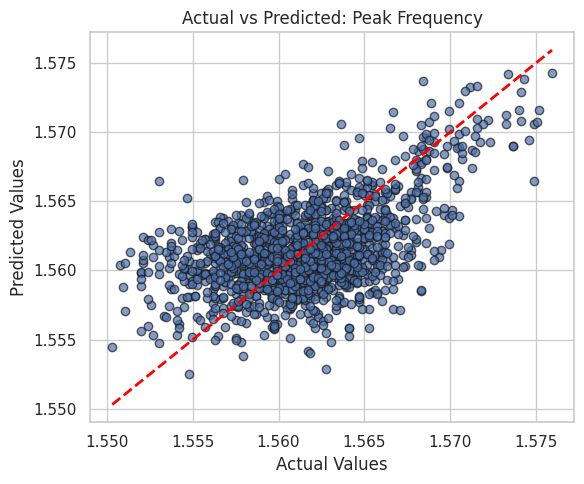

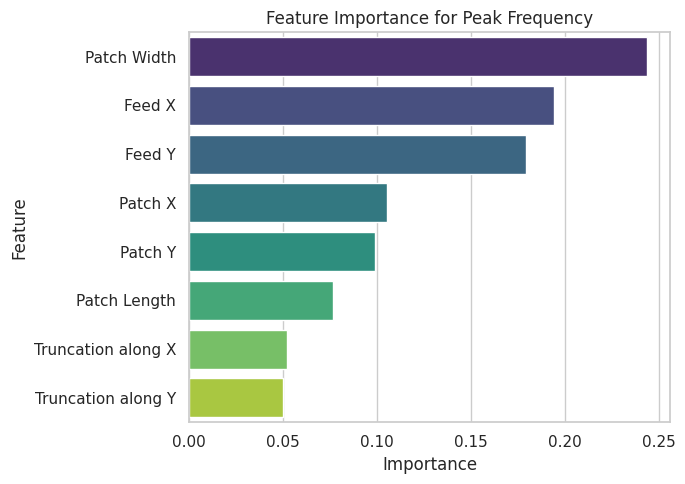


 Plots for: S11 dB value


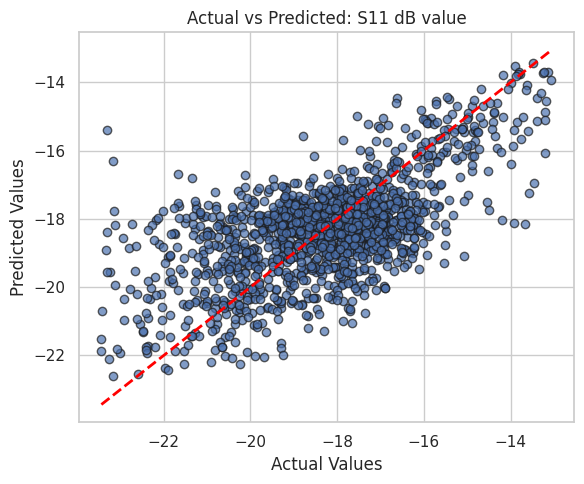

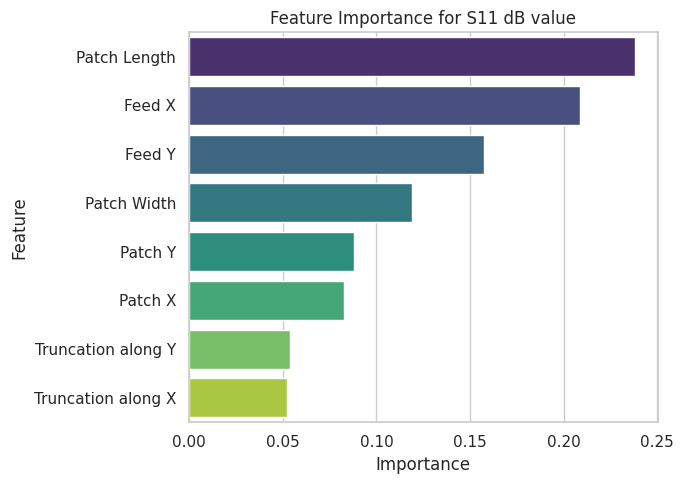


 Plots for: Axial Ratio at Fr (dB)


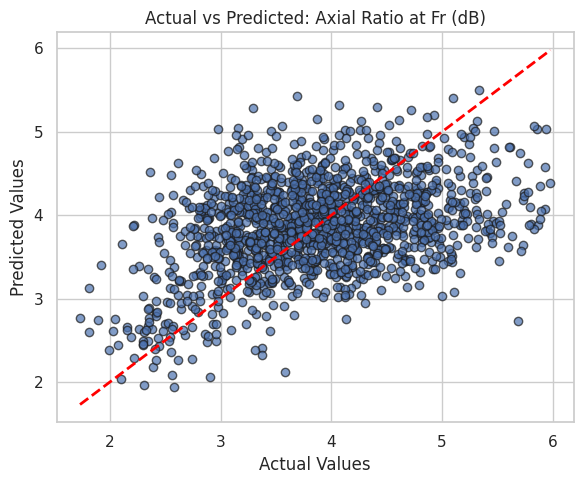

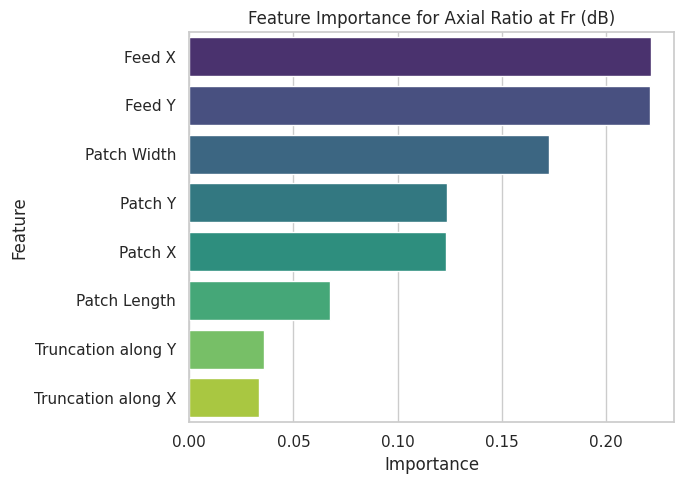


Overall Model Performance Summary:

         Output Parameter       MAE      RMSE        R²
0          Peak Frequency  0.002841  0.003560  0.241667
1            S11 dB value  1.159173  1.489939  0.389269
2  Axial Ratio at Fr (dB)  0.601522  0.753400  0.076932


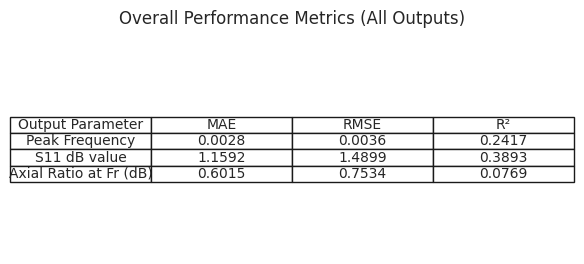

In [ ]:
# --- Set plot style ---
sns.set(style="whitegrid")

all_metrics = []

# --- Loop through each stored model ---
for target, info in rf_models.items():

    print(f"\n==============================")
    print(f" Plots for: {target}")
    print(f"==============================")


    y_test = info['y_test']
    y_pred = info['y_pred']
    importance = info['importance']
    metrics = info['metrics']

    # ===============================
    # 1. Actual vs Predicted Plot
    # ===============================
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linestyle='--', linewidth=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted: {target}")
    plt.tight_layout()
    plt.show()

    # ===============================
    # 2. Feature Importance Plot
    # ===============================
    plt.figure(figsize=(7, 5))
    sns.barplot(x='Importance', y='Parameter', data=importance, palette='viridis')
    plt.title(f"Feature Importance for {target}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    # --- Store metrics for summary table ---
    all_metrics.append({
        'Output Parameter': target,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R²': metrics['R2']
    })


# ===============================
# 3. Combined Metrics Table (after loop)
# ===============================
# all_metrics.remove(all_metrics[1])
metrics_summary = pd.DataFrame(all_metrics)
print("\nOverall Model Performance Summary:\n")
print(metrics_summary)

# --- Table Plot ---
plt.figure(figsize=(6, len(metrics_summary) * 0.6 + 1))
plt.axis('off')
table = plt.table(cellText=metrics_summary.round(4).values,
                  colLabels=metrics_summary.columns,
                  cellLoc='center',
                  loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
plt.title("Overall Performance Metrics (All Outputs)", pad=15)
plt.tight_layout()
plt.show()


Overall Model Performance
MAE  = 0.6015220760197092
RMSE = 0.7534003000281744
R²   = 0.07693160281323896


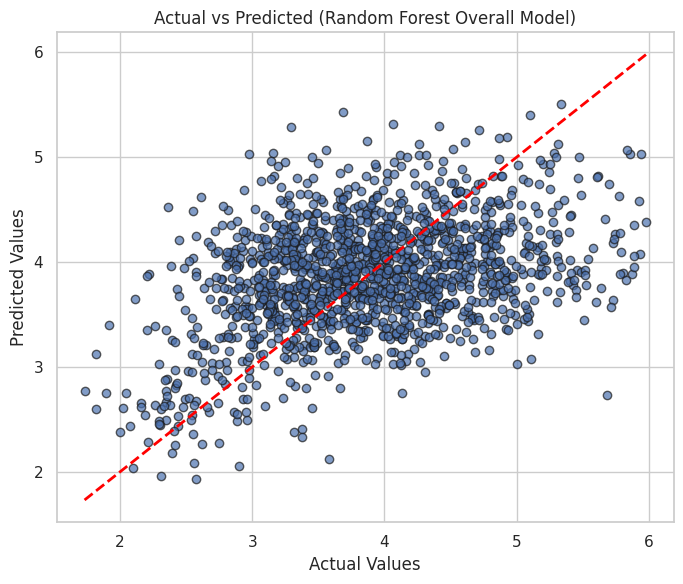

In [ ]:
# --- Split your data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train overall Random Forest model ---
overall_rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
overall_rf_model.fit(X_train, y_train)

# --- Predictions ---
y_pred = overall_rf_model.predict(X_test)

# --- Regression metrics ---
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# --- Overall combined metrics (same values here, but kept for clarity) ---
overall_mae = mae
overall_mse = mse
overall_rmse = rmse
overall_r2 = r2

print("\n==============================")
print("Overall Model Performance")
print("==============================")
print(f"MAE  = {overall_mae}")
print(f"RMSE = {overall_rmse}")
print(f"R²   = {overall_r2}")

# ===============================
# Actual vs Predicted Plot
# ===============================
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted (Random Forest Overall Model)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
cv_scores = cross_val_score(overall_rf_model, X, y, cv=5, scoring='r2')  # Using R² score

# Calculate mean and standard deviation
mean_score = np.mean(cv_scores)
std_dev = np.std(cv_scores)

print("==============================")
print("Cross-Validation Performance")
print("==============================")
print(f"Mean R² Score       = {mean_score}")
print(f"Standard Deviation  = {std_dev}")

Cross-Validation Performance
Mean R² Score       = -0.7431810006743051
Standard Deviation  = 0.3684705639256504
